# Chapter 6, Example 3: Tree-reweighted upper bounds

The Bethe entropy counts every edge mutual information with coefficient one.  Tree-reweighted inference replaces these coefficients by edge-appearance probabilities $\rho_{ij}$ obtained from a probability distribution over spanning trees:

$$
H_{\mathrm{TRW}}(\boldsymbol b;\boldsymbol\rho)
=
\sum_i H(b_i)-\sum_{(i,j)}\rho_{ij}I_{ij}(b_{ij}).
$$

If $\boldsymbol\rho$ belongs to the spanning-tree polytope, then

$$
\log Z
\leq
\max_{\boldsymbol b\in\mathcal L}
\left\{
\mathbb E_{\boldsymbol b}[\log \psi]
+H_{\mathrm{TRW}}(\boldsymbol b;\boldsymbol\rho)
\right\}.
$$

The local polytope $\mathcal L$ enforces nonnegativity, normalization, and pairwise-to-singleton marginal consistency.  For the triangle, the uniform distribution over its three spanning trees gives $\rho_{ij}=2/3$ for every edge.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import minimize

CWD = Path.cwd()
if CWD.name == "ch06":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch06").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch06"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

NODE_COLOR = "#30343b"
NODE_TEXT_COLOR = "white"


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


def entropy(probabilities):
    p = np.asarray(probabilities, dtype=float)
    mask = p > 0
    return -np.sum(p[mask] * np.log(p[mask]))


def binary_entropy_from_magnetization(m):
    m = np.asarray(m, dtype=float)
    q = np.clip((1.0 + m) / 2.0, 1e-15, 1.0 - 1e-15)
    return -(q * np.log(q) + (1.0 - q) * np.log(1.0 - q))

In [2]:
N = 3
EDGES = [(0, 1), (1, 2), (0, 2)]
BASE_COUPLINGS = {(0, 1): 0.75, (1, 2): -0.50, (0, 2): 0.62}
FIELDS = np.array([0.13, -0.06, 0.09])
SPINS = np.array([-1, 1])
STATES = np.array(list(product([-1, 1], repeat=N)), dtype=int)


def exact_log_z(scale):
    logw = np.array([
        sum(scale * BASE_COUPLINGS[e] * s[e[0]] * s[e[1]] for e in EDGES) + np.dot(FIELDS, s)
        for s in STATES
    ])
    shift = logw.max()
    return shift + np.log(np.exp(logw - shift).sum())


def pair_table(mi, mj, cij):
    table = np.zeros((2, 2))
    for a, si in enumerate(SPINS):
        for b, sj in enumerate(SPINS):
            table[a, b] = 0.25 * (1 + si * mi + sj * mj + si * sj * cij)
    return table


def local_objective(vector, scale, rho):
    m = vector[:N]
    c = vector[N:]
    energy = np.dot(FIELDS, m)
    node_entropy = binary_entropy_from_magnetization(m).sum()
    information = 0.0
    for index, edge in enumerate(EDGES):
        i, j = edge
        table = pair_table(m[i], m[j], c[index])
        energy += scale * BASE_COUPLINGS[edge] * c[index]
        information += rho[index] * (
            entropy((1 + m[i] * SPINS) / 2)
            + entropy((1 + m[j] * SPINS) / 2)
            - entropy(table)
        )
    return energy + node_entropy - information


def constraints(vector):
    m = vector[:N]
    c = vector[N:]
    values = []
    for index, (i, j) in enumerate(EDGES):
        values.extend(pair_table(m[i], m[j], c[index]).ravel() - 1e-10)
    return np.asarray(values)


def optimize_local(scale, rho, start=None):
    if start is None:
        start = np.zeros(N + len(EDGES))
    result = minimize(
        lambda vector: -local_objective(vector, scale, rho),
        start,
        method="SLSQP",
        bounds=[(-0.999999, 0.999999)] * (N + len(EDGES)),
        constraints={"type": "ineq", "fun": constraints},
        options={"ftol": 1e-12, "maxiter": 2000},
    )
    if not result.success:
        raise RuntimeError(result.message)
    return result.x, -result.fun


def optimize_mean_field(scale):
    def objective(m):
        interaction = sum(scale * BASE_COUPLINGS[e] * m[e[0]] * m[e[1]] for e in EDGES)
        return interaction + np.dot(FIELDS, m) + binary_entropy_from_magnetization(m).sum()
    best = None
    for start in [np.zeros(N), 0.8 * np.ones(N), -0.8 * np.ones(N), RNG.uniform(-0.8, 0.8, N)]:
        result = minimize(lambda m: -objective(m), start, method="L-BFGS-B", bounds=[(-0.999999, 0.999999)] * N)
        if best is None or result.fun < best.fun:
            best = result
    return best.x, -best.fun

## Spanning-tree mixture

Saved: figs/ch06_03_spanning_tree_mixture.pdf


Saved: figs/ch06_03_spanning_tree_mixture.png


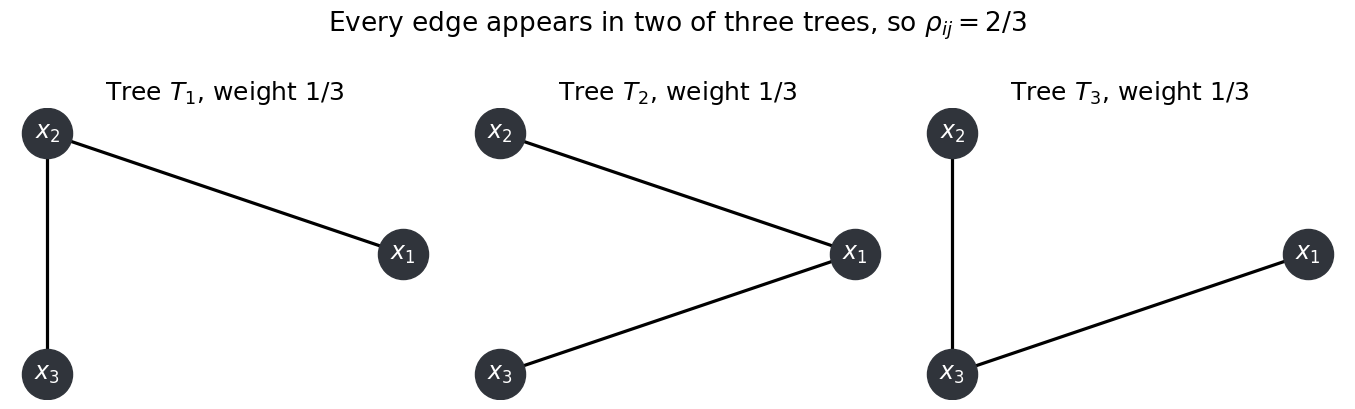

In [3]:
TREES = [
    [(0, 1), (1, 2)],
    [(0, 1), (0, 2)],
    [(1, 2), (0, 2)],
]
fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.2))
pos = nx.circular_layout(nx.Graph(EDGES))
for index, (ax, tree_edges) in enumerate(zip(axes, TREES), start=1):
    graph = nx.Graph()
    graph.add_nodes_from(range(N))
    graph.add_edges_from(tree_edges)
    nx.draw_networkx_nodes(graph, pos, node_size=1300, node_color=NODE_COLOR, ax=ax)
    nx.draw_networkx_labels(graph, pos, labels={i: rf"$x_{i+1}$" for i in range(N)},
                            font_size=17, font_color=NODE_TEXT_COLOR, ax=ax)
    nx.draw_networkx_edges(graph, pos, width=2.3, ax=ax)
    ax.set_title(rf"Tree $T_{index}$, weight $1/3$")
    ax.axis("off")
fig.suptitle(r"Every edge appears in two of three trees, so $\rho_{ij}=2/3$")
fig.tight_layout()
save_figure(fig, "ch06_03_spanning_tree_mixture")
plt.show()

## Variational lower and upper bounds

Saved: figs/ch06_03_variational_bounds.pdf


Saved: figs/ch06_03_variational_bounds.png


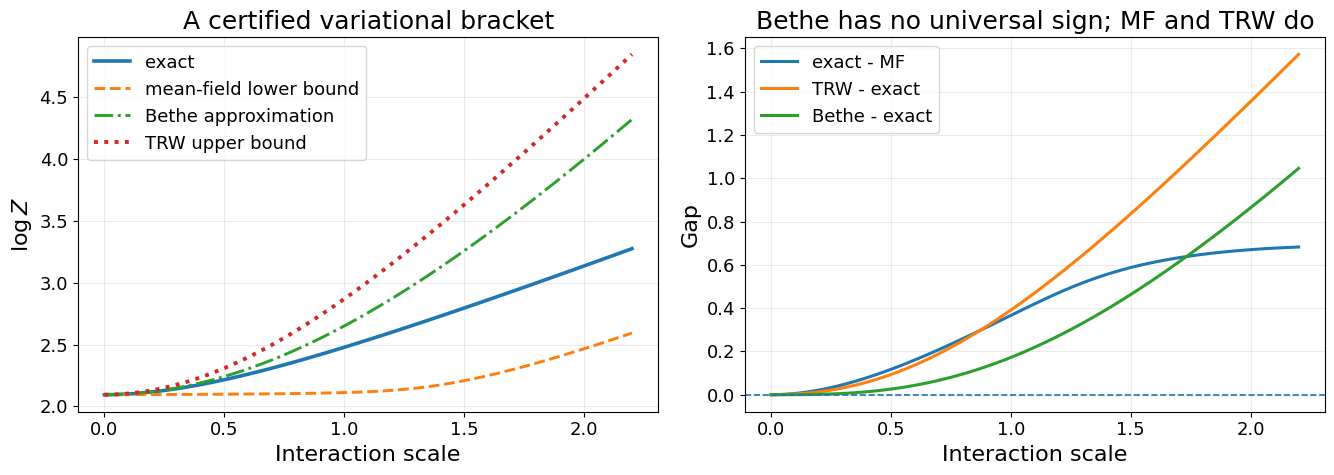

In [4]:
scale_grid = np.linspace(0.0, 2.2, 55)
exact_values = []
mf_values = []
bethe_values = []
trw_values = []
start_bethe = None
start_trw = None
for scale in scale_grid:
    exact_values.append(exact_log_z(scale))
    _, mf_value = optimize_mean_field(scale)
    start_bethe, bethe_value = optimize_local(scale, np.ones(len(EDGES)), start_bethe)
    start_trw, trw_value = optimize_local(scale, np.full(len(EDGES), 2.0 / 3.0), start_trw)
    mf_values.append(mf_value)
    bethe_values.append(bethe_value)
    trw_values.append(trw_value)

exact_values = np.asarray(exact_values)
mf_values = np.asarray(mf_values)
bethe_values = np.asarray(bethe_values)
trw_values = np.asarray(trw_values)

assert np.all(mf_values <= exact_values + 2e-7)
assert np.all(trw_values >= exact_values - 2e-7)

fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.0))
axes[0].plot(scale_grid, exact_values, linewidth=2.6, label="exact")
axes[0].plot(scale_grid, mf_values, linestyle="--", linewidth=2.1, label="mean-field lower bound")
axes[0].plot(scale_grid, bethe_values, linestyle="-.", linewidth=2.1, label="Bethe approximation")
axes[0].plot(scale_grid, trw_values, linestyle=":", linewidth=2.8, label="TRW upper bound")
axes[0].set_xlabel("Interaction scale")
axes[0].set_ylabel(r"$\log Z$")
axes[0].set_title("A certified variational bracket")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(scale_grid, exact_values - mf_values, linewidth=2.2, label="exact - MF")
axes[1].plot(scale_grid, trw_values - exact_values, linewidth=2.2, label="TRW - exact")
axes[1].plot(scale_grid, bethe_values - exact_values, linewidth=2.2, label="Bethe - exact")
axes[1].axhline(0, linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Interaction scale")
axes[1].set_ylabel("Gap")
axes[1].set_title("Bethe has no universal sign; MF and TRW do")
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.tight_layout()
save_figure(fig, "ch06_03_variational_bounds")
plt.show()

## How reweighting changes entropy counting

Saved: figs/ch06_03_entropy_reweighting.pdf
Saved: figs/ch06_03_entropy_reweighting.png


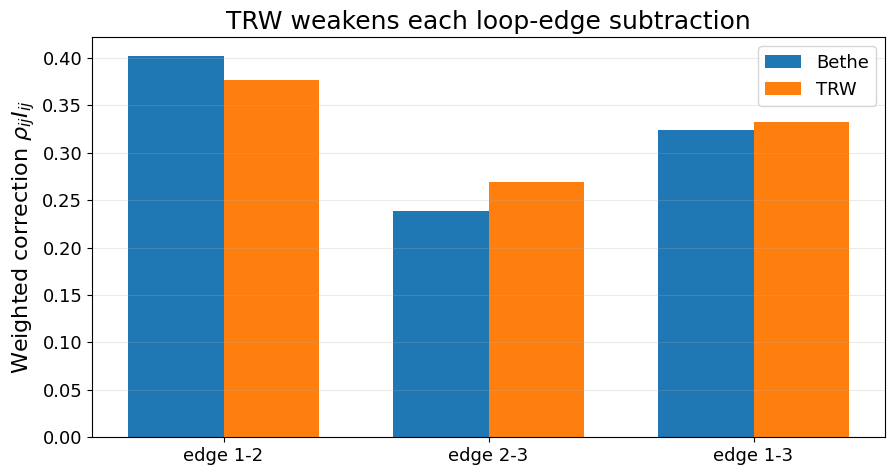

In [5]:
scale = 1.6
bethe_solution, _ = optimize_local(scale, np.ones(len(EDGES)))
trw_solution, _ = optimize_local(scale, np.full(len(EDGES), 2 / 3))

rows = []
for name, solution, rho in [
    ("Bethe", bethe_solution, np.ones(len(EDGES))),
    ("TRW", trw_solution, np.full(len(EDGES), 2 / 3)),
]:
    m = solution[:N]
    c = solution[N:]
    for k, (i, j) in enumerate(EDGES):
        table = pair_table(m[i], m[j], c[k])
        information = entropy((1 + m[i] * SPINS) / 2) + entropy((1 + m[j] * SPINS) / 2) - entropy(table)
        rows.append({"approximation": name, "edge": f"{i+1}-{j+1}", "rho*I": rho[k] * information})
frame = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9.2, 5.0))
x = np.arange(len(EDGES))
width = 0.36
for offset, name in [(-width / 2, "Bethe"), (width / 2, "TRW")]:
    values = frame[frame["approximation"] == name]["rho*I"].to_numpy()
    ax.bar(x + offset, values, width, label=name)
ax.set_xticks(x, [f"edge {i+1}-{j+1}" for i, j in EDGES])
ax.set_ylabel(r"Weighted correction $\rho_{ij}I_{ij}$")
ax.set_title("TRW weakens each loop-edge subtraction")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
save_figure(fig, "ch06_03_entropy_reweighting")
plt.show()

## Exercises

1. **Basic.** Replace the uniform tree distribution by arbitrary nonnegative tree weights that sum to one.  Verify the induced edge-appearance probabilities.
2. **Extension.** Optimize the tree weights numerically to tighten the upper bound for this triangle.
3. **Structural.** Repeat the calculation on a four-node cycle and describe the spanning-tree polytope.
4. **Research.** Compare the TRW marginal estimates with exact marginals.  Does a tighter bound on $\log Z$ necessarily imply more accurate marginals?